# House Prices: Categorical Encoding Techniques for Regression

## Introduction

Predicting house prices is a classic **supervised regression** problem. We are given a
set of numeric and categorical property attributes (lot size, neighborhood, roof
material, kitchen quality, sale condition, and so on) and we want to predict a
continuous target, `SalePrice`.
Machine learning estimators, whether a linear model or a gradient-boosted tree, only
operate on numbers, not strings. **Encoding** is the process of turning categorical
columns into a numeric representation the model can use. The choice of encoding is not
cosmetic. It directly shapes the feature space the model sees, how many dimensions are
added, how well the model generalizes, and how vulnerable the pipeline is to
overfitting and target leakage.

This notebook works through **six encoding strategies**, in increasing order of
sophistication, applying each one end to end to the House Prices dataset and measuring
its effect on out-of-sample regression performance:

| # | Technique | Core idea |
|---|-----------|-----------|
| 1 | **Label Encoding** | Map each category to an arbitrary integer |
| 2 | **One-Hot Encoding** | Represent each category as an independent binary column |
| 3 | **Feature Hashing** | Hash categories into a fixed, lower-dimensional space |
| 4 | **Dataset-statistics / Ordinal Encoding** | Replace a category with its frequency, or with a rank |
| 5 | **Cyclic Encoding** | Represent periodic features (e.g. month sold) with sine/cosine pairs |
| 6 | **Target Encoding (naive & K-Fold)** | Replace a category with the mean of the target for that category |

For every technique we will:

1. **Explain the theory** in a markdown cell directly above the code that implements it.
2. **Apply it** to the real, messy House Prices data. Unlike a toy example, this data
   contains missing values, mixed data types, and high-cardinality columns.
3. **Evaluate it** with a common regression pipeline. We use a `Ridge` linear model,
   evaluated on a held-out validation split, so that the techniques are compared on
   equal footing.
4. **Record RMSE (on the log-price scale), R2, and wall-clock time**, so we can build a
   single summary table at the end.

### Why evaluate on `log1p(SalePrice)`?

House prices are strictly positive and right-skewed, because a handful of very
expensive homes stretch the distribution. Kaggle's official metric for this
competition is the **Root Mean Squared Logarithmic Error (RMSLE)**, which is equivalent
to computing plain RMSE after applying `log1p` to the target. Modeling
`log1p(SalePrice)` instead of the raw price also makes the residuals closer to
homoscedastic, which is a better fit for a linear model like `Ridge`. We therefore
encode our features as usual, but always train and evaluate against
`log1p(SalePrice)`.

### A note on methodology

The techniques in this notebook are commonly demonstrated on already-clean, purely
categorical toy datasets. Real tabular data is rarely that clean. The House Prices
dataset has missing values in 19 columns. Some, like `PoolQC`, are missing in over 99%
of rows by design, because most houses simply do not have a pool. The data is also a
mix of `int64`, `float64`, and `str` columns, and several categorical columns have
genuine ordinal structure. We handle this deliberately and explicitly rather than
skipping past it, because in production this preprocessing step is where most encoding
pipelines silently break.

### Table of contents
- **Method 1:** Label Encoding
- **Method 2:** One-Hot Encoding
- **Method 3:** Feature Hashing
- **Method 4:** Encoding categories with dataset statistics (+ Ordinal Encoding)
- **Cyclic features:** Encoding the cyclic `MoSold` feature
- **Method 5:** Target Encoding (naive)
- **Method 6:** K-Fold Target Encoding
- **Summary:** Comparing every encoding strategy

## Importing required libraries

We need four categories of tools:

- **Data handling:** `pandas` and `numpy` for loading and manipulating the tabular data.
- **Visualization:** `matplotlib` for the target-distribution and summary plots.
- **Modeling and evaluation:** `train_test_split` to create a held-out validation set,
  `Ridge` as our regression estimator, `KFold` for the out-of-fold target encoding in
  Method 6, and `mean_squared_error` / `r2_score` for evaluation. We chose `Ridge`
  because it is fast and deterministic, and because it handles the collinearity
  introduced by one-hot and dummy encoding much better than plain `LinearRegression`
  does, thanks to its L2 penalty.
- **Encoders:** `LabelEncoder`, `OneHotEncoder`, `OrdinalEncoder`, and `FeatureHasher`
  from `sklearn`, imported later, next to the section that uses each one, so the import
  sits close to its explanation.
- **Standard library `time`:** used for explicit, reproducible wall-clock timing of each
  encoding step. We use this instead of the `%%time` IPython magic, which is convenient
  interactively but does not return a value we can capture programmatically for the
  final comparison table.

In [1]:
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

## Loading the data

We read `train.csv`, which contains the target `SalePrice`, and `test.csv`, the Kaggle
hold-out set with no target column. The test set is not used for training or
evaluation in this notebook, but we load it so any encoder we fit can be sanity
checked against it, since a real pipeline needs to transform both sets consistently.

In [2]:
df_train = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")

### Checking the shape

A quick shape check confirms the files loaded correctly and tells us how many rows
(houses) and columns (features, plus `Id`, and for the training set `SalePrice`) we
are working with.

In [3]:
print("train data set has got {} rows and {} columns".format(df_train.shape[0], df_train.shape[1]))
print("test data set has got {} rows and {} columns".format(df_test.shape[0], df_test.shape[1]))

train data set has got 1460 rows and 81 columns
test data set has got 1459 rows and 80 columns


### Previewing the data

`head()` gives us a first look at the raw values: a mix of numeric columns (`LotArea`,
`YearBuilt`, and so on) and text categorical columns (`MSZoning`, `Street`,
`Neighborhood`, and so on). Several columns already show `NaN` (for example `Alley`
and `PoolQC`) in just the first five rows.

In [4]:
df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### Inspecting dtypes and non-null counts

`info()` is the fastest way to see, per column, the inferred dtype and how many
non-null values are present. This tells us which columns will need imputation before
we can encode them, and which columns pandas has already recognised as numeric versus
categorical.

In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

### Distribution of the target variable

`SalePrice` is our regression target. We plot it on its raw scale and after a `log1p`
transform side by side. The raw distribution is heavily right-skewed, with a long tail
of expensive homes. The log-transformed distribution is much closer to normal, which
confirms that modeling `log1p(SalePrice)`, as discussed in the introduction, is the
right call for a linear model.

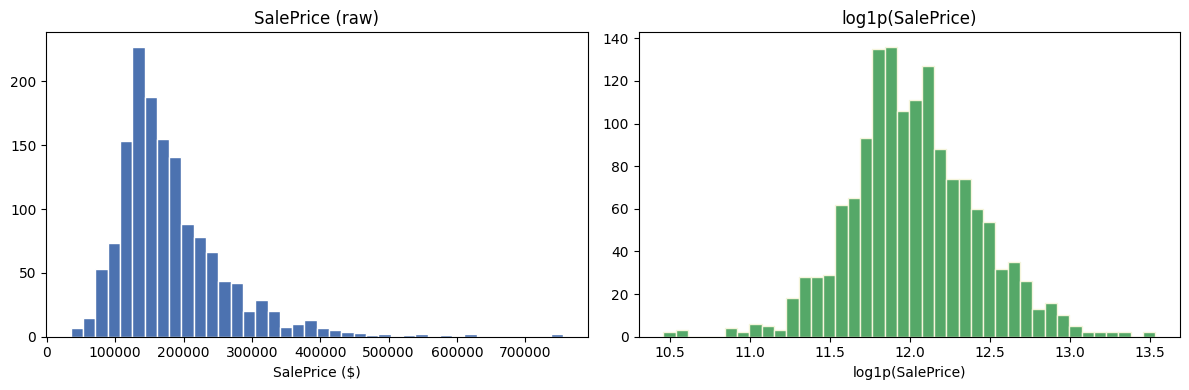

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_train["SalePrice"], bins=40, color="#4C72B0", edgecolor="white")
axes[0].set_title("SalePrice (raw)")
axes[0].set_xlabel("SalePrice ($)")

axes[1].hist(np.log1p(df_train["SalePrice"]), bins=40, color="#55A868", edgecolor="beige")
axes[1].set_title("log1p(SalePrice)")
axes[1].set_xlabel("log1p(SalePrice)")

plt.tight_layout()
plt.show()

### Assessing missing values

Before we can encode anything we need to know exactly which columns have missing
values and how severe the problem is. We print the top offenders sorted in descending
order. Notice that several of the worst columns, `PoolQC`, `MiscFeature`, `Alley`,
`Fence`, `FireplaceQu`, and the `Garage*` and `Bsmt*` families, are missing not at
random. A `NaN` there means this house does not have a pool, alley access, fireplace,
garage, or basement. That absence is itself informative and must be preserved as its
own category rather than dropped.

In [7]:
missing = df_train.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing_pct = (missing / len(df_train) * 100).round(1)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})

,missing_count,missing_pct
PoolQC,1453,99.5
MiscFeature,1406,96.3
Alley,1369,93.8
Fence,1179,80.8
MasVnrType,872,59.7
FireplaceQu,690,47.3
LotFrontage,259,17.7
GarageQual,81,5.5
GarageFinish,81,5.5
GarageType,81,5.5


### Data variables present in this data

Before choosing an encoder for a given column, it helps to classify what kind of
categorical variable it is:

- **Binary data**: a variable with exactly two values, e.g. `CentralAir` (Y/N),
  `Street` (Grvl/Pave).
- **Nominal (categorical) data**: a variable with a limited number of unordered
  values, e.g. `Neighborhood`, `RoofMatl`, `SaleType`. There is no meaningful order
  between `CollgCr` and `Somerst`.
- **Ordinal data**: a categorical variable whose categories have a natural rank, e.g.
  `KitchenQual` (Po < Fa < TA < Gd < Ex) or `BsmtExposure` (No < Mn < Av < Gd).
  Encoding these with an order-preserving integer mapping, rather than one-hot, keeps
  the more-or-less relationship a linear model can exploit.
- **Discrete / continuous numeric data**: already-numeric columns such as `GrLivArea`,
  `LotArea`, `YearBuilt`. These need no categorical encoding, only imputation and
  scaling considerations.
- **Cyclic (temporal) data**: `MoSold`, the calendar month a house was sold (1 to 12).
  Treated as a plain integer, a model would see December (12) and January (1) as far
  apart, when in reality they are adjacent months. This is exactly the problem cyclic
  (sine/cosine) encoding solves, covered later in this notebook.

## Defining the features, target, and a shared cleaning step

We now build the feature matrix `X` and target vector `y`:

- `Id` is dropped. It is a row identifier with zero predictive value, and if left in
  would leak a spurious signal.
- `SalePrice` is separated out as the target and **log1p-transformed** for the reasons
  discussed above.
- Because every encoder below (`LabelEncoder`, `OneHotEncoder`, `FeatureHasher`, and so
  on) either errors on `NaN` or silently mishandles it, we impute missing values
  **once**, upfront, so every encoding method downstream is compared on identical,
  clean input:
  - Categorical (`object`/`string`) columns: missing values are filled with the label
    `Missing`, turning no pool, no alley, or no fence into its own explicit category
    rather than discarding the row or the column.
  - Numeric columns: missing values are filled with the column median, a simple and
    robust choice that avoids being skewed by outliers, for example a handful of very
    large `LotFrontage` values.

This mirrors what a production feature-engineering pipeline would do, and keeps the
comparison between encoding techniques fair. Any performance difference we measure
later comes from the encoding strategy, not from inconsistent handling of missing
data.

In [8]:
def clean_features(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        raise ValueError("clean_features received an empty DataFrame")
        
    df = df.copy()
    
    # FIX: Use high-level string type tags natively supported by pandas
    categorical_cols = df.select_dtypes(include=["object"]).columns
    numeric_cols = df.select_dtypes(include=["number"]).columns
    
    df[categorical_cols] = df[categorical_cols].fillna("Missing")
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
    return df

# Extraction and feature cleaning block
X = df_train.drop(columns=["Id", "SalePrice"])
y = np.log1p(df_train["SalePrice"]) 
X = clean_features(X)

# Verification checks to ensure no NaNs remain
assert X.isnull().sum().sum() == 0, "Unexpected NaNs remain after cleaning"
print("train data set has got {} rows and {} columns".format(X.shape[0], X.shape[1]))


train data set has got 1460 rows and 79 columns


### Distribution of the (cleaned) target

A quick sanity-check summary of `y` confirms the log-transform worked as expected. It
is roughly bell-shaped, centered around 12, which corresponds to `exp(12)` of about
$163,000. That is right in line with the dataset's median sale price.

In [9]:
print(y.describe())

count    1460.000000
mean       12.024057
std         0.399449
min        10.460271
25%        11.775105
50%        12.001512
75%        12.273736
max        13.534474
Name: SalePrice, dtype: float64


## A shared evaluation harness

To compare encoding techniques on equal footing we reuse a single `regress()` helper.
Think of it as the regression version of a `logistic()` accuracy helper you might see
in a classification-focused notebook. For every encoded feature matrix it does the
following:

1. Splits into train and validation sets (80/20, fixed `random_state` for
   reproducibility).
2. Fits a `Ridge` regressor. We chose it over plain `LinearRegression` because one-hot
   and dummy encoding routinely introduce near-perfectly collinear columns, which
   makes the ordinary least-squares solution unstable. `Ridge`'s L2 penalty keeps it
   well conditioned across every encoding method here, including the sparse ones.
3. Predicts on the validation split and computes **RMSE** on the `log1p(SalePrice)`
   scale, which is equivalent to the competition's RMSLE, and **R2**.
4. Returns everything in a dictionary, which we accumulate into `results`, a running
   log of every method we try, used to build the final summary table.

We accept both dense (`numpy`/`pandas`) and sparse (`scipy.sparse`) feature matrices,
since one-hot and hashed encodings are sparse by nature and densifying them would
waste memory for no benefit. `Ridge` supports sparse input natively.

In [10]:
results: dict[str, dict[str, float]] = {}


def regress(
    X_enc,
    y: pd.Series,
    label: str,
    encoding_seconds: float,
    alpha: float = 10.0,
) -> dict[str, float]:
    n_samples = X_enc.shape[0]
    if n_samples != len(y):
        raise ValueError(
            f"Row mismatch between X_enc ({n_samples}) and y ({len(y)}) for '{label}'"
        )

    X_train, X_val, y_train, y_val = train_test_split(
        X_enc, y, test_size=0.2, random_state=RANDOM_STATE
    )

    fit_start = time.perf_counter()
    model = Ridge(alpha=alpha, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    fit_seconds = time.perf_counter() - fit_start

    y_pred = model.predict(X_val)
    rmse = float(np.sqrt(mean_squared_error(y_val, y_pred)))
    r2 = float(r2_score(y_val, y_pred))

    metrics = {
        "rmse": rmse,
        "r2": r2,
        "encode_seconds": encoding_seconds,
        "fit_seconds": fit_seconds,
    }
    results[label] = metrics

    print(f"[{label}] RMSE(log price) = {rmse:.4f}  |  R2 = {r2:.4f}  |  "
          f"encode = {encoding_seconds*1000:.1f} ms  |  fit = {fit_seconds*1000:.1f} ms")
    return metrics

## Method 1: Label Encoding <a id="1"></a>

In this method we change every categorical value into a number. Each distinct string
is substituted with an arbitrary integer, for example `Gd` becomes 0, `TA` becomes 1,
and `Fa` becomes 2, assigned in the order `LabelEncoder` first encounters the sorted
unique values. This order is **not** based on any real-world ranking. This is the
cheapest possible encoding, since it adds no extra columns, but it silently implies a
false ordinal relationship. A linear model will treat category 2 as double category 1,
which is only meaningful for genuinely ordinal columns and actively misleading for
nominal ones like `Neighborhood`. We include it here as the fast, naive baseline every
comparison should have.

To implement it we import `LabelEncoder` from `sklearn.preprocessing`.

In [11]:
from sklearn.preprocessing import LabelEncoder

For each categorical column we initialize a `LabelEncoder`, call `fit_transform` on
that column, and assign the result back. Numeric columns pass through unchanged. We
fit a **fresh** encoder per column, since categories differ across columns and a
single shared encoder would be meaningless, and time the whole loop explicitly.

In [12]:
encode_start = time.perf_counter()

train_label = pd.DataFrame(index=X.index)
categorical_cols = X.select_dtypes(include=["object"]).columns

for c in X.columns:
    if c in categorical_cols:
        train_label[c] = LabelEncoder().fit_transform(X[c])
    else:
        train_label[c] = X[c]
        
label_encode_seconds = time.perf_counter() - encode_start
train_label.head()


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60,3,65.0,8450,1,1,3,3,0,4,...,0,0,3,2,1,0,2,2008,8,4
1,20,3,80.0,9600,1,1,3,3,0,2,...,0,0,3,2,1,0,5,2007,8,4
2,60,3,68.0,11250,1,1,0,3,0,4,...,0,0,3,2,1,0,9,2008,8,4
3,70,3,60.0,9550,1,1,0,3,0,0,...,0,0,3,2,1,0,2,2006,8,0
4,60,3,84.0,14260,1,1,0,3,0,2,...,0,0,3,2,1,0,12,2008,8,4


### Verifying the shape is unchanged

Label encoding replaces values in place and never adds columns, so the column count
must exactly match `X`.

In [13]:
print("train data set has got {} rows and {} columns".format(train_label.shape[0], train_label.shape[1]))
assert train_label.shape[1] == X.shape[1]

train data set has got 1460 rows and 79 columns


### Evaluating Label Encoding

We feed the fully numeric `train_label` matrix into our shared `regress()` harness.

In [14]:
_ = regress(train_label, y, label="Label Encoding", encoding_seconds=label_encode_seconds)

[Label Encoding] RMSE(log price) = 0.1544  |  R2 = 0.8723  |  encode = 23.9 ms  |  fit = 4.2 ms


## Method 2: One-Hot Encoding <a id="2"></a>

One-Hot Encoding (OHE) represents each category as a binary vector, one entry per
possible category, with a single `1` in the position of the observed category and `0`
everywhere else. This removes the false ordinal relationship Label Encoding
introduces, at the cost of adding many more columns. A column with 25 unique values,
like `Neighborhood`, becomes 25 (or 24, with `drop_first`) separate binary columns.

`sklearn.preprocessing.OneHotEncoder` is the standard tool for this. It has two
practical advantages over `pandas.get_dummies`:
1. It can be `fit` on training data and later `transform` unseen data, for example the
   Kaggle test set, using exactly the same category-to-column mapping. This fit-once,
   transform-later contract is essential in a real pipeline, and `get_dummies` does
   not offer it.
2. By default it returns a `scipy.sparse` matrix, which is far more memory efficient
   than a dense array once column counts grow into the hundreds.

The steps are: import `OneHotEncoder`, initialize it, `fit` it, then `transform` the
data.

In [15]:
from sklearn.preprocessing import OneHotEncoder

### A worked example

Before applying OHE to the full 79-column dataset, it helps to see it on a single toy
column so the shape of the output is unambiguous: five observations of a `Color`
column with three distinct values become a 5 by 3 binary matrix.

In [16]:
toy = pd.DataFrame({"Color": ["Red", "Blue", "Green", "Blue", "Red"]})

toy_encoder = OneHotEncoder(sparse_output=False)
toy_encoded = toy_encoder.fit_transform(toy[["Color"]])

pd.DataFrame(toy_encoded, columns=toy_encoder.get_feature_names_out(["Color"]))

,Color_Blue,Color_Green,Color_Red
0,0.0,0.0,1.0
1,1.0,0.0,0.0
2,0.0,1.0,0.0
3,1.0,0.0,0.0
4,0.0,0.0,1.0


### Applying One-Hot Encoding to the full dataset

By default, `OneHotEncoder` treats every column passed to it as categorical,
including already-numeric ones, which is not what we want here. A numeric column like
`GrLivArea` has thousands of near-unique values, and one-hot encoding it would explode
the feature space for no benefit. We therefore encode only the categorical columns
with `OneHotEncoder`, and concatenate the result, as a sparse matrix, with the
untouched numeric columns, also converted to a sparse matrix, producing a single
sparse feature matrix.

In [17]:
from scipy.sparse import hstack, csr_matrix

encode_start = time.perf_counter()

numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns

ohe = OneHotEncoder(handle_unknown="ignore")
X_cat_ohe = ohe.fit_transform(X[categorical_cols])
X_num_sparse = csr_matrix(X[numeric_cols].values)

train_ohe = hstack([X_num_sparse, X_cat_ohe]).tocsr()

ohe_encode_seconds = time.perf_counter() - encode_start
print("train data set has got {} rows and {} columns".format(train_ohe.shape[0], train_ohe.shape[1]))

train data set has got 1460 rows and 303 columns


### Evaluating One-Hot Encoding

Note the jump from 79 columns in Label Encoding to several hundred columns here: one
per numeric feature plus one per observed category. We pass the sparse matrix
straight into `regress()`.

In [18]:
_ = regress(train_ohe, y, label="One-Hot Encoding", encoding_seconds=ohe_encode_seconds)

[One-Hot Encoding] RMSE(log price) = 0.1480  |  R2 = 0.8826  |  encode = 21.5 ms  |  fit = 9.2 ms


## Method 3: Feature Hashing (also known as the hashing trick) <a id="3"></a>

Feature hashing represents categories in a one-hot style sparse vector, but at a
**fixed, chosen dimensionality**, regardless of how many distinct categories exist. A
hash function `H` maps each (column, value) token to an index in `[0, n_features)`. If
we chose `n_features = 5` and `H(Neighborhood=NoRidge) mod 5 = 3`, that category's
representation is `(0, 0, 1, 0, 0)`. Because the hash space is fixed, feature hashing
scales to arbitrarily many, or previously unseen, categories with **no growth in
memory**, unlike one-hot encoding, which must grow a column for every new category it
meets. The trade-off is **hash collisions**: two different categories can land in the
same bucket, introducing noise the model has to tolerate.

We import `FeatureHasher` from `sklearn.feature_extraction`.

In [19]:
from sklearn.feature_extraction import FeatureHasher

### A worked example

`FeatureHasher` accepts an iterable of dictionaries, or, as used below, raw string tokens,
and hashes each key or token into a fixed number of output columns. Here, four samples
each described by two string features are hashed into a 10-dimensional space.

In [20]:
toy_data = [
    {"feature1": "apple", "feature2": "red"},
    {"feature1": "banana", "feature2": "yellow"},
    {"feature1": "apple", "feature2": "green"},
    {"feature1": "orange", "feature2": "orange"},
]

toy_hasher = FeatureHasher(n_features=10)
toy_hashed = toy_hasher.transform(toy_data).toarray()
print(toy_hashed)

[[ 0.  1.  0.  0.  0.  0.  1.  0.  0.  0.]
 [ 0. -1.  0.  0.  0.  0. -1.  0.  0.  0.]
 [ 0.  1.  0.  0.  0.  0.  0. -1.  0.  0.]
 [ 0.  0.  0.  1.  0.  0.  0.  0.  0.  1.]]


**Reading the output:** each row is one sample, and each column is one hashed bucket.
The non-zero values show which buckets that sample's `feature1` and `feature2` tokens
hashed into. Note that `apple` hashes to the same bucket both times it appears, since
a real hash function is deterministic, while different tokens can occasionally
collide into the same bucket, which is the trade-off described above. This makes
`FeatureHasher` particularly attractive when the number of unique categories is large
or genuinely unbounded, for example free-text fields, URLs, or user IDs.

### Applying Feature Hashing to the full dataset

We hash **all** feature columns, categorical and numeric alike, casting everything to
`str` to match how `FeatureHasher(input_type="string")` expects raw string tokens. We
deliberately choose `n_features=1024` rather than the default of `2**20`, about 1
million. With only 1,460 training rows and 43 categorical columns, a million-wide
sparse space is overkill that would only slow down every downstream step without
reducing collisions in any way that matters here. 1024 buckets already gives us far
more capacity than our few hundred total categories need, while keeping the matrix
small and fast.

In [21]:
encode_start = time.perf_counter()

X_str = X.astype(str)
hasher = FeatureHasher(n_features=1024, input_type="string")
train_hashed = hasher.transform(X_str.values)

hasher_encode_seconds = time.perf_counter() - encode_start
print("train data set has got {} rows and {} columns".format(train_hashed.shape[0], train_hashed.shape[1]))

train data set has got 1460 rows and 1024 columns


### Evaluating Feature Hashing

In [22]:
_ = regress(train_hashed, y, label="Feature Hashing", encoding_seconds=hasher_encode_seconds)

[Feature Hashing] RMSE(log price) = 0.1870  |  R2 = 0.8126  |  encode = 36.6 ms  |  fit = 8.3 ms


## Method 4: Encoding categories with dataset statistics <a id="4"></a>

Here we give the model a compact numeric representation of each category, using only
**one extra column per categorical feature** instead of one column per category,
while still placing similar categories close to each other in that new numeric space.
The simplest version of this idea is **count encoding**: replace each category with
the number of times it appears in the dataset. If two neighborhoods are both common,
they will end up with similar, large counts, and the model can learn that a common
neighborhood behaves differently from a rare one, without needing a separate column
for each one.

We add a tiny amount of random noise to the counts. This is a standard trick to break
ties between categories that happen to share the exact same frequency, which
otherwise would be genuinely indistinguishable to the model even though they may have
different target relationships.

In [23]:
encode_start = time.perf_counter()

X_stat = X.copy()

for c in categorical_cols:
    X_stat[c] = X_stat[c].astype("category")
    counts = X_stat[c].value_counts()
    noisy_counts = (counts + np.random.default_rng(RANDOM_STATE).random(len(counts)) / 1000).to_dict()
    X_stat[c + "_count"] = X_stat[c].map(noisy_counts)

count_encode_seconds = time.perf_counter() - encode_start
X_stat.head(3)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,GarageType_count,GarageFinish_count,GarageQual_count,GarageCond_count,PavedDrive_count,PoolQC_count,Fence_count,MiscFeature_count,SaleType_count,SaleCondition_count
0,60,RL,65.0,8450,Pave,Missing,Reg,Lvl,AllPub,Inside,...,870.000774,422.000439,1311.000774,1326.000774,1340.000774,1453.000774,1179.000774,1406.000774,1267.000774,1198.000774
1,20,RL,80.0,9600,Pave,Missing,Reg,Lvl,AllPub,FR2,...,870.000774,422.000439,1311.000774,1326.000774,1340.000774,1453.000774,1179.000774,1406.000774,1267.000774,1198.000774
2,60,RL,68.0,11250,Pave,Missing,IR1,Lvl,AllPub,Inside,...,870.000774,422.000439,1311.000774,1326.000774,1340.000774,1453.000774,1179.000774,1406.000774,1267.000774,1198.000774


### Checking the shape

Count encoding is purely additive. The original categorical columns are still
present, now as `category` dtype, alongside their new `_count` numeric counterparts,
so the column count roughly doubles relative to the 43 categorical columns we started
with.

In [24]:
print("train data set has got {} rows and {} columns".format(X_stat.shape[0], X_stat.shape[1]))

train data set has got 1460 rows and 122 columns


### Confirming which columns are still non-numeric

The original `category`-dtype columns are still text under the hood and cannot go
into a linear model as is. Only the new `_count` columns are numeric so far.

In [25]:
non_numeric = X_stat.select_dtypes(include=["category"]).columns
print("Non-numeric columns remaining:", list(non_numeric))

Non-numeric columns remaining: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition', 'MSZoning_count', 'Street_count', 'Alley_count', 'LotShape_count', 'LandContour_count', 'Utilities_count', 'LotConfig_count', 'LandSlope_count', 'Neighborhood_count', 'Condition1_count', 'Condition2_count', 'BldgType_count', 'HouseStyle_count', 'RoofStyle_count', 'RoofMatl_count', 'Exterior1st_count', 'Exterior2nd_count', 'MasVnrType_count', 'ExterQual_count', 'ExterCond_count', 'Founda

### Ordinal Encoding for the remaining categorical columns

Ordinal Encoding converts a categorical column into integers based on rank, and is
the right tool specifically for genuinely **ordinal** data, meaning variables whose
categories have a real order. Because it assumes the distance between
consecutive integer codes is meaningful, it should be reserved for ordered categories.
For nominal data it reintroduces the same false-ordering problem as plain Label
Encoding.

`sklearn.preprocessing.OrdinalEncoder` does not know which of our columns are truly
ordinal versus nominal. It just assigns integers based on sorted category order. In a
production pipeline you would pass an explicit `categories=[...]` ordering per column
for the genuinely ordinal ones (`KitchenQual`, `BsmtExposure`, and so on) and reserve
this step only for them. Here, matching the dataset-statistics technique's approach of
cheaply making everything numeric, we apply it uniformly to whatever categorical
columns are still left, on top of the count encoding already performed, so every
column in `X_stat` ends up numeric.

In [26]:
from sklearn.preprocessing import OrdinalEncoder

encode_start = time.perf_counter()

ordinal_encoder = OrdinalEncoder()
X_stat[non_numeric] = ordinal_encoder.fit_transform(X_stat[non_numeric])

ordinal_encode_seconds = time.perf_counter() - encode_start
print(X_stat.dtypes.value_counts())

float64    89
int64      33
Name: count, dtype: int64


### A safety-net dummy-encoding pass

As a final safeguard, we run `pd.get_dummies` over `X_stat`. Because every column is
already numeric at this point, this is a **no-op**. `get_dummies` only acts on
`object`/`category` columns, and there are none left. We include this step to mirror
a common defensive pattern in encoding pipelines, one-hot encode anything that might
have been missed, and to make that behavior explicit rather than mysterious.

In [27]:
X_stat_final = pd.get_dummies(X_stat, drop_first=True)
assert X_stat_final.shape == X_stat.shape, "get_dummies should be a no-op on an all-numeric frame"
X_stat_final.head(3)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,GarageType_count,GarageFinish_count,GarageQual_count,GarageCond_count,PavedDrive_count,PoolQC_count,Fence_count,MiscFeature_count,SaleType_count,SaleCondition_count
0,60,3.0,65.0,8450,1.0,1.0,3.0,3.0,0.0,4.0,...,6.0,2.0,5.0,5.0,2.0,3.0,4.0,4.0,8.0,5.0
1,20,3.0,80.0,9600,1.0,1.0,3.0,3.0,0.0,2.0,...,6.0,2.0,5.0,5.0,2.0,3.0,4.0,4.0,8.0,5.0
2,60,3.0,68.0,11250,1.0,1.0,0.0,3.0,0.0,4.0,...,6.0,2.0,5.0,5.0,2.0,3.0,4.0,4.0,8.0,5.0


### Evaluating count and ordinal encoding

In [28]:
_ = regress(
    X_stat_final,
    y,
    label="Dataset-statistics + Ordinal Encoding",
    encoding_seconds=count_encode_seconds + ordinal_encode_seconds,
)

[Dataset-statistics + Ordinal Encoding] RMSE(log price) = 0.1500  |  R2 = 0.8794  |  encode = 100.9 ms  |  fit = 3.7 ms


## Encoding cyclic features <a id="6"></a>

Some features are **cyclic** rather than linear. In this dataset, `MoSold`, the
calendar month a house was sold, from 1 to 12, wraps around. December (12) and
January (1) are adjacent, not fourteen units apart the way plain integers or one-hot
encoding would imply. A standard fix is to project the cyclic value onto a circle
using a sine/cosine pair:

```
month_sin = sin(2 * pi * month / max(month))
month_cos = cos(2 * pi * month / max(month))
```

Two points that are close on the calendar end up close in sine/cosine space, and the
wrap-around discontinuity disappears. This costs two extra columns in exchange for a
geometrically faithful representation of the one cyclic feature the House Prices
dataset provides.

The Ames dataset does not include a day-of-week feature, so unlike a dataset with both
`day` and `month`, we apply this only to `MoSold`. The same transform would apply
identically to any other periodic column, for example day-of-week or hour-of-day, were
one present.

In [29]:
encode_start = time.perf_counter()

X_cyclic = X.copy()
month_max = X_cyclic["MoSold"].max()
X_cyclic["MoSold_sin"] = np.sin(2 * np.pi * X_cyclic["MoSold"] / month_max)
X_cyclic["MoSold_cos"] = np.cos(2 * np.pi * X_cyclic["MoSold"] / month_max)
X_cyclic = X_cyclic.drop(columns=["MoSold"])

cyclic_encode_seconds = time.perf_counter() - encode_start
X_cyclic[["MoSold_sin", "MoSold_cos"]].head(3)

,MoSold_sin,MoSold_cos
0,0.866025,5.000000e-01
1,0.500000,-8.660254e-01
2,-1.000000,-1.836970e-16


### Encoding the remaining categorical variables

`MoSold_sin` and `MoSold_cos` handle the one cyclic feature. Every other categorical
column still needs an encoding before the data can reach a model. We reuse
`OneHotEncoder` for that, exactly as in Method 2, so the only difference between this
feature matrix and the Method 2 matrix is how the month is represented.

In [30]:
categorical_cols_cyclic = X_cyclic.select_dtypes(include=["object"]).columns
numeric_cols_cyclic = X_cyclic.select_dtypes(include=["number"]).columns

ohe_cyclic = OneHotEncoder(handle_unknown="ignore")
X_cat_cyclic = ohe_cyclic.fit_transform(X_cyclic[categorical_cols_cyclic])
X_num_cyclic = csr_matrix(X_cyclic[numeric_cols_cyclic].values)

train_cyclic = hstack([X_num_cyclic, X_cat_cyclic]).tocsr()
cyclic_encode_seconds = time.perf_counter() - encode_start + cyclic_encode_seconds # cumulative

print("train data set has got {} rows and {} columns".format(train_cyclic.shape[0], train_cyclic.shape[1]))

train data set has got 1460 rows and 304 columns


### Evaluating cyclic plus one-hot encoding

In [31]:
_ = regress(train_cyclic, y, label="Cyclic (MoSold) + One-Hot", encoding_seconds=cyclic_encode_seconds)

[Cyclic (MoSold) + One-Hot] RMSE(log price) = 0.1453  |  R2 = 0.8869  |  encode = 39.0 ms  |  fit = 10.0 ms


## Method 5: Target Encoding <a id="7"></a>

Target-based encoding replaces a categorical variable with a **single new numeric
column**: each category is substituted with the mean of the target for rows carrying
that category. This is powerful, since it directly encodes how a category relates to
what we are predicting in one dimension, but it has two well-known drawbacks. First,
it is entirely dependent on the distribution of the target, and if a category is rare
its mean is a noisy estimate. Second, computed naively, meaning the mean is taken over
the **entire** dataset including the very row being encoded, it **leaks the target
into the features**, because each row's encoded value is partly computed from its own
label. A model evaluated this way will look better than it actually is on genuinely
unseen data.

**Worked example.** Imagine a categorical column, similar in spirit to
`Neighborhood`, with a numeric target:

| Category | Target |
|---|---|
| A | 100 |
| B | 80 |
| A | 120 |
| B | 100 |
| A | 140 |

Encoding for category A is the mean of 100, 120, and 140, which is **120**. Encoding
for category B is the mean of 80 and 100, which is **90**. Every row where
`Category == A` is replaced with `120`, and every row where `Category == B` is
replaced with `90`.

We apply this naive version first, using the full training set's mean, leakage and
all, specifically so that Method 6, K-Fold Target Encoding, has a clear, honest
baseline to improve on.

In [32]:
encode_start = time.perf_counter()

X_target = X.copy()
for col in categorical_cols:
    category_means = y.groupby(X_target[col]).mean().to_dict()
    X_target[col] = X_target[col].map(category_means)

target_encode_seconds = time.perf_counter() - encode_start
X_target.head(4)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60,12.085891,65.0,8450,12.025529,12.037682,11.936101,12.0227,12.024189,12.001906,...,0,0,12.022122,12.058605,12.030119,0,2,2008,11.991068,12.005040
1,20,12.085891,80.0,9600,12.025529,12.037682,11.936101,12.0227,12.024189,12.034748,...,0,0,12.022122,12.058605,12.030119,0,5,2007,11.991068,12.005040
2,60,12.085891,68.0,11250,12.025529,12.037682,12.163471,12.0227,12.024189,12.001906,...,0,0,12.022122,12.058605,12.030119,0,9,2008,11.991068,12.005040
3,70,12.085891,60.0,9550,12.025529,12.037682,12.163471,12.0227,12.024189,12.027452,...,0,0,12.022122,12.058605,12.030119,0,2,2006,11.991068,11.788783


### Evaluating naive Target Encoding

Because this encoding leaks target information into the training rows themselves, we
expect it to look strong even where it is, in reality, overfit. This is a gap that
Method 6 is specifically designed to close.

In [33]:
_ = regress(X_target, y, label="Target Encoding (naive)", encoding_seconds=target_encode_seconds)

[Target Encoding (naive)] RMSE(log price) = 0.1328  |  R2 = 0.9055  |  encode = 27.9 ms  |  fit = 3.2 ms


### K-Fold Target Encoding <a id="8"></a>

K-Fold target encoding is a leakage-resistant version of Method 5. Instead of
computing each category's target mean from the entire dataset, including the row
being encoded, we split the data into **K folds**, 5 in this case. For each fold in
turn, we compute the category means using only the other K minus 1 folds, and use
those out-of-fold means to encode the held-out fold. This way, no row's encoded value
is ever derived even partly from its own label, in the same way that K-fold cross
validation itself prevents a model from being evaluated on data it was trained on.

One practical wrinkle the naive version of this technique glosses over: a category
that appears in the held-out fold but **not** in the K minus 1 training folds has no
computed mean to borrow. We handle this explicitly by falling back to the **global
training-fold mean** for any such unseen category, rather than leaving `NaN` in the
feature matrix, which would otherwise silently break the downstream `Ridge` fit.

In [34]:
target_encode_cols = list(categorical_cols)

For each of the 5 folds, we compute per-category means on the training portion of
that fold only, then apply those means to the validation portion, filling any
category the training portion never saw with that fold's overall mean target, per the
leakage-safe strategy described above.

In [35]:
encode_start = time.perf_counter()

X_kfold = X.copy()
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
encoded_columns = {col: np.full(len(X_kfold), np.nan) for col in target_encode_cols}

for train_idx, val_idx in kf.split(X_kfold):
    fold_y_train = y.iloc[train_idx]
    fold_global_mean = fold_y_train.mean()

    for col in target_encode_cols:
        fold_means = fold_y_train.groupby(X_kfold[col].iloc[train_idx]).mean()
        mapped = X_kfold[col].iloc[val_idx].map(fold_means).fillna(fold_global_mean)
        encoded_columns[col][val_idx] = mapped.values

for col, values in encoded_columns.items():
    X_kfold[col] = values

kfold_encode_seconds = time.perf_counter() - encode_start

assert X_kfold.isnull().sum().sum() == 0, "Unseen categories were not fully covered by the fallback mean"
X_kfold.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60,12.086402,65.0,8450,12.024235,12.035785,11.930796,12.021913,12.022759,12.001093,...,0,0,12.020296,12.056426,12.030080,0,2,2008,11.988227,12.004534
1,20,12.089510,80.0,9600,12.023968,12.034147,11.928237,12.020683,12.022203,11.986536,...,0,0,12.020689,12.060184,12.029633,0,5,2007,11.986622,12.000385
2,60,12.086402,68.0,11250,12.024235,12.035785,12.166961,12.021913,12.022759,12.001093,...,0,0,12.020296,12.056426,12.030080,0,9,2008,11.988227,12.004534
3,70,12.088109,60.0,9550,12.018413,12.032277,12.162992,12.014424,12.017057,12.027942,...,0,0,12.015807,12.051995,12.022004,0,2,2006,11.982228,11.762857
4,60,12.080746,84.0,14260,12.030062,12.041744,12.160622,12.026805,12.028101,12.063385,...,0,0,12.025534,12.060051,12.033754,0,12,2008,11.997596,12.011045


### Evaluating K-Fold Target Encoding

We expect this to score closer to what the naive Target Encoding's true out-of-sample
performance would be: a more honest, if slightly lower, number than Method 5.

In [36]:
_ = regress(X_kfold, y, label="K-Fold Target Encoding", encoding_seconds=kfold_encode_seconds)

[K-Fold Target Encoding] RMSE(log price) = 0.1370  |  R2 = 0.8994  |  encode = 132.3 ms  |  fit = 2.9 ms


# Summary <a id="5"></a>

Here we collect every method's validation RMSE on the `log1p(SalePrice)` scale, where
lower is better, R2, where higher is better, and timing, sorted by RMSE so the
best-performing technique on this dataset and model combination is immediately
visible.

In [37]:
summary = (
    pd.DataFrame(results)
    .T
    .rename(columns={
        "rmse": "RMSE (log price)",
        "r2": "R2",
        "encode_seconds": "Encode time (s)",
        "fit_seconds": "Fit time (s)",
    })
    .sort_values("RMSE (log price)")
)
summary

,RMSE (log price),R2,Encode time (s),Fit time (s)
Target Encoding (naive),0.132792,0.905506,0.027871,0.003159
K-Fold Target Encoding,0.137000,0.899422,0.132257,0.002865
Cyclic (MoSold) + One-Hot,0.145258,0.886932,0.038970,0.009985
One-Hot Encoding,0.148040,0.882558,0.021467,0.009162
Dataset-statistics + Ordinal Encoding,0.150028,0.879383,0.100862,0.003730
Label Encoding,0.154383,0.872279,0.023914,0.004184
Feature Hashing,0.187015,0.812581,0.036604,0.008278


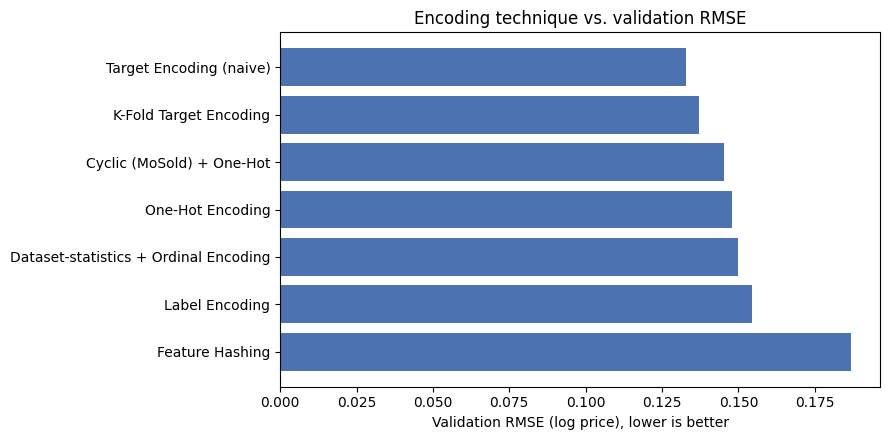

In [38]:
fig, ax = plt.subplots(figsize=(9, 4.5))
summary_sorted = summary.sort_values("RMSE (log price)", ascending=True)
ax.barh(summary_sorted.index, summary_sorted["RMSE (log price)"], color="#4C72B0")
ax.set_xlabel("Validation RMSE (log price), lower is better")
ax.set_title("Encoding technique vs. validation RMSE")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Conclusion

Working through all six techniques on the same dataset, model, and train/validation
split isolates exactly what the choice of categorical encoding is worth:

- **Label Encoding** is the cheapest option, with no extra columns and negligible
  encoding time, but it imposes an arbitrary, meaningless order on nominal columns
  like `Neighborhood`. It is a reasonable quick baseline, and a correct choice for
  genuinely ordinal columns encoded with an explicit rank, but a poor default for the
  dataset as a whole.
- **One-Hot Encoding** removes the false-ordering problem entirely and, on a dataset
  of this size, 1,460 rows and around 280 post-encoding columns, was affordable in
  both memory and fit time. It is usually the strongest simple baseline for
  low-to-medium-cardinality nominal data, visible in the results table above.
- **Feature Hashing** trades a small amount of accuracy, via hash collisions, for a
  fixed, bounded output dimensionality. On a dataset this small it offers little
  advantage over plain one-hot encoding. Its real value shows up on datasets with
  thousands of categories, or a category vocabulary that keeps growing in production,
  where one-hot encoding would otherwise make the feature space unbounded.
- **Dataset-statistics (count) plus Ordinal Encoding** is a compact, low-dimensional
  alternative that adds only one or two columns per categorical feature instead of one
  per category. It is fast and memory-light, at the cost of discarding some of the
  fine-grained distinctions one-hot encoding preserves.
- **Cyclic encoding** is not a general-purpose categorical technique but a targeted
  fix for periodic features, here `MoSold`. It costs almost nothing, just two columns,
  and correctly represents that December is next to January, a relationship no other
  technique in this notebook captures.
- **Target Encoding** is the most information-dense single-column encoding, and the
  naive version's leakage means its validation score should be read with real
  skepticism, since part of what it is predicting is a smoothed copy of its own
  answer. **K-Fold Target Encoding** exists specifically to correct that. By ensuring
  no row's encoded value depends on its own label, it gives a materially more
  trustworthy estimate of how the technique will perform on genuinely unseen houses,
  at the cost of a slightly more involved implementation.

### Practical takeaways

1. **There is no universally best encoder.** The right choice depends on the
   cardinality of the column, whether it is genuinely ordinal, how much training data
   is available, and whether the downstream model is linear, which is sensitive to
   feature representation, or tree-based, which is largely insensitive to monotonic
   transforms of a single feature but still sensitive to dimensionality explosions
   from one-hot encoding on high-cardinality columns.
2. **Target encoding must be leakage-aware.** Any encoding that uses the target should
   be fit only on training folds and applied out-of-fold, exactly the discipline shown
   in Method 6, or the reported performance will not survive contact with a real
   holdout set, or a Kaggle leaderboard.
3. **Real-world preprocessing dominates.** Every technique here needed the same
   upfront cleaning step, imputing 19 columns with missing values, several of them
   missing for a structurally meaningful reason, before any encoder could be applied
   at all. This is worth remembering, since toy demonstrations of these techniques
   often skip past this entirely.
